### This notebook is designed to understand and implement the important concepts from California Housing as under Geron's Ch2

Various steps of a ML End to End project
1) Big Picture understanding of the problem
2) Get the Data
3) Explore and Visualise the data
4) Preprocess the Data
5) Select a Model
6) Fine-Tune the model parameters
7) Present the solution
8) Launch, Monitor.. etc

## Get the Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import tarfile
import pandas as pd
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

C:\Users\Taif Al Ghazali\AppData\Local\Temp\ipykernel_23204\1618124921.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


## Time to Explore this data

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


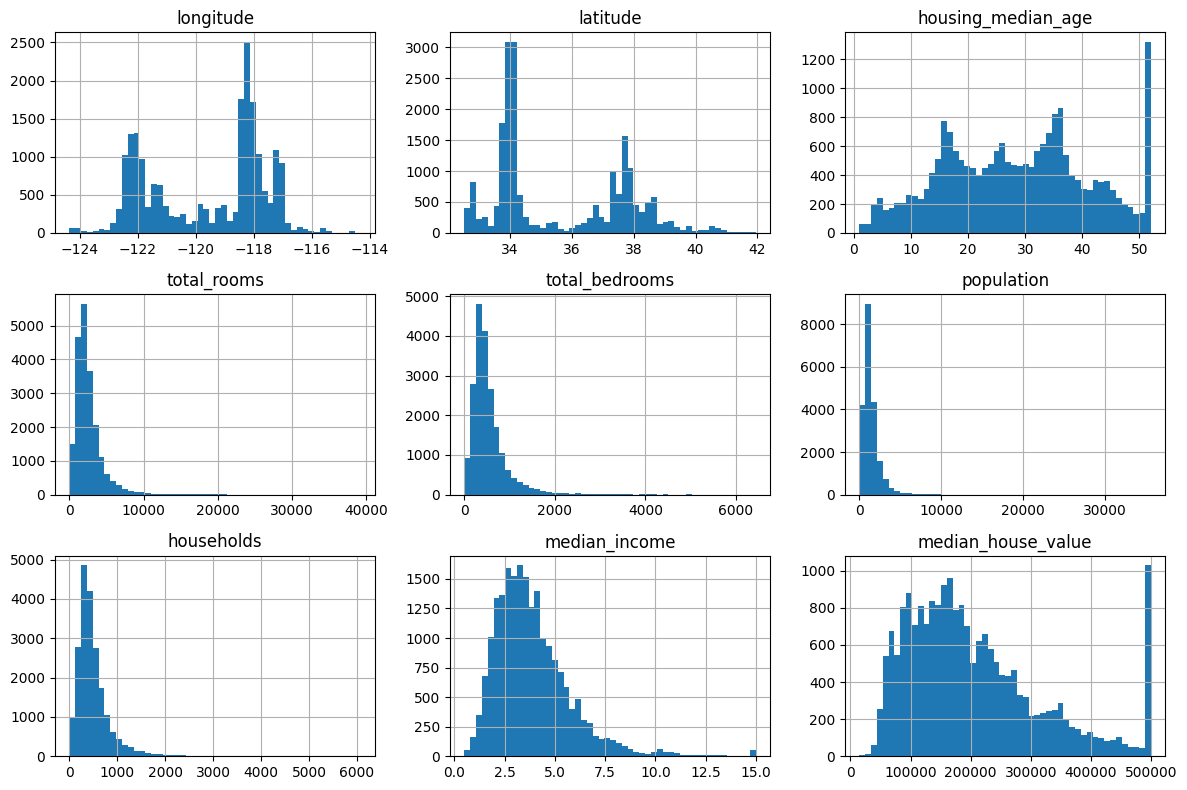

In [6]:
housing.hist(bins=50, figsize= (12,8))
plt.tight_layout()
plt.show()

***We can notice that there are quite a few features over here which are 'skewed' right... we will have to take care of them before the final solution.***

In [7]:
housing[housing["population"] > 20000]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9795,-121.79,36.64,11.0,32627.0,6445.0,28566.0,6082.0,2.3087,118800.0,<1H OCEAN
12594,-117.42,33.35,14.0,25135.0,4819.0,35682.0,4769.0,2.5729,134400.0,<1H OCEAN


*So clearly, we can see that the population and it's correlated features (total bedrooms.. etc) is massively skewed right. extremities are pretty high*

*We've been told that the **housing median age** and **median house value** features have been capped at max*

### Seperating the train and test sets

*Essential to do this before we do any further data exploration/ preprocessing*

*Any changes we make to the train set, be it addition/ removal of features or taking care of **NaN** values, we must reciprocate that in the test set as well*

*It is rumored that **median income** has a high importance in deciding what the median house value will be. We should make sure our test and train set are representative of the original distribution*

*Hence, we have to **stratify** our train, test split*

In [8]:
housing["median_income"].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

In [9]:
housing[housing["median_income"] > 6.0].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,2362.000000,2362.000000,2362.000000,2362.000000,2337.000000,2362.000000,2362.000000,2362.000000,2362.000000
mean,-119.607570,35.336232,25.574090,3398.914479,502.565682,1389.890347,480.190517,7.722912,378671.235394
std,2.005111,1.894027,12.959644,2953.054535,446.832445,1274.766529,412.177573,1.931465,101810.220917
min,-122.720000,32.610000,2.000000,8.000000,1.000000,13.000000,1.000000,6.005000,67500.000000
25%,-121.990000,33.850000,16.000000,1817.500000,267.000000,727.000000,260.250000,6.379100,293500.000000
50%,-118.500000,34.170000,25.000000,2671.000000,394.000000,1076.500000,381.000000,7.032750,371800.000000
75%,-117.920000,37.430000,34.750000,3983.500000,583.000000,1637.750000,569.750000,8.242750,500001.000000
max,-115.390000,40.120000,52.000000,37937.000000,5471.000000,16122.000000,5189.000000,15.000100,500001.000000


In [10]:
housing['income_cat'] = pd.cut(housing['median_income'], bins= [0, 1.5, 3.0, 4.5, 6.0, np.inf], labels = [1,2,3,4,5])

<Axes: xlabel='income_cat'>

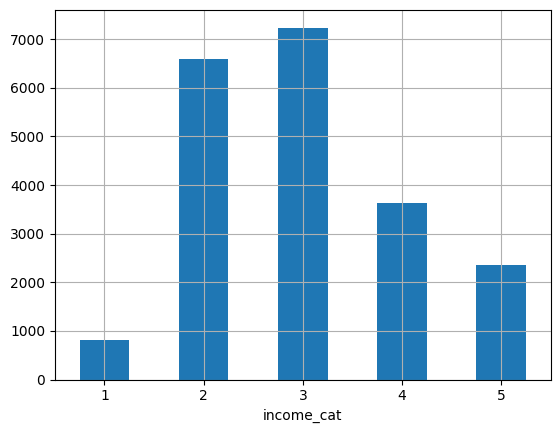

In [11]:
housing['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid= True)

In [12]:
from sklearn.model_selection import train_test_split
train_set, test_set  = train_test_split(housing, test_size=0.2)

In [13]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 851 to 4045
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16346 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  object  
 10  income_cat          16512 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.4+ MB


In [14]:
strat_train_set, strat_test_set  = train_test_split(housing, stratify=housing['income_cat'], test_size=0.2)

In [15]:
housing['income_cat'].value_counts()/ len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [16]:
train_set['income_cat'].value_counts()/ len(train_set)

income_cat
3    0.349806
2    0.319404
4    0.179930
5    0.112282
1    0.038578
Name: count, dtype: float64

In [17]:
strat_train_set['income_cat'].value_counts()/ len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

*Clearly, the difference is'nt much but if it is a highly important feature, it matters*

In [18]:
for set_ in (train_set, test_set):
    set_.drop('income_cat', axis =1 , inplace= True)

In [19]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis =1 , inplace= True)

We would not need the income_cat feature any more

### Exploring Geographical Aspects of the data

In [20]:
housing = strat_train_set.copy() ## have a copy of training set

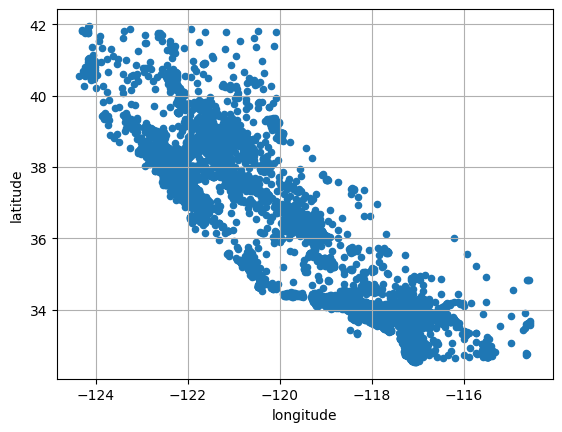

In [21]:
housing.plot(kind="scatter", x= 'longitude', y= 'latitude', grid= True)
plt.show()

*To make the population density more visible, we introduce **alpha***

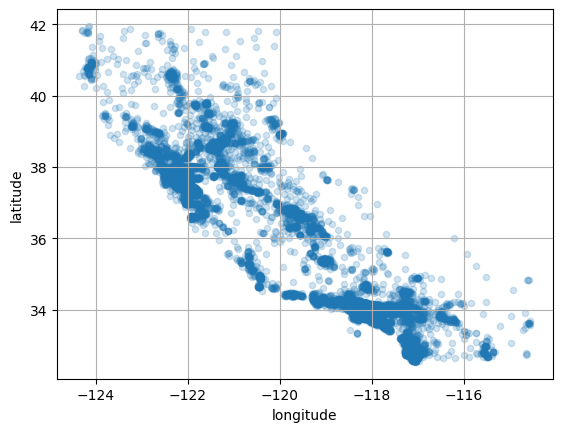

In [22]:
housing.plot(kind="scatter", x= 'longitude', y= 'latitude', alpha=0.2, grid= True) 
plt.show()

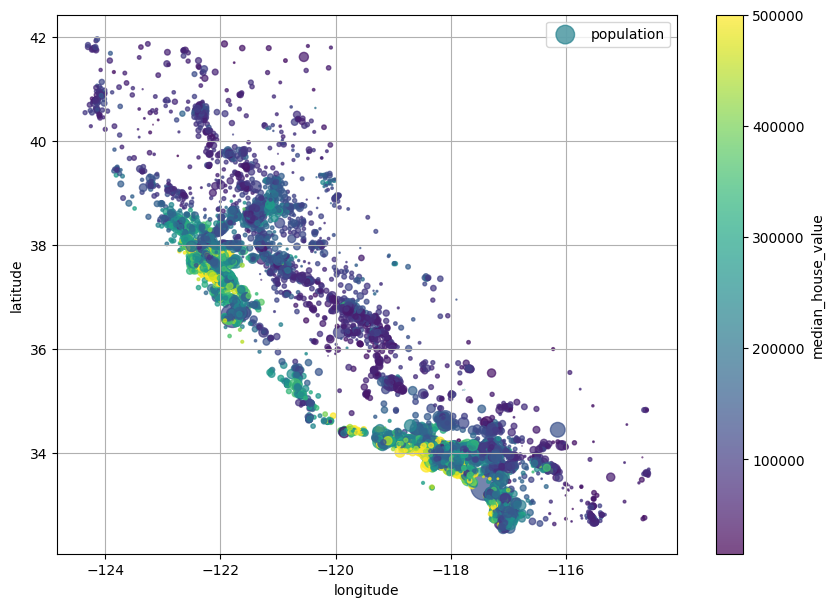

In [23]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid = True, 
            s= housing['population']/100, label = "population", alpha= 0.7, 
            c= "median_house_value", cmap = 'viridis', colorbar= True, 
            legend = True, sharex= False, figsize = (10,7))

plt.show()

### Exploring Correlations

In [24]:
corr_matrix= housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending= False)

median_house_value    1.000000
median_income         0.686589
total_rooms           0.129365
housing_median_age    0.109071
households            0.063986
total_bedrooms        0.048503
population           -0.025065
longitude            -0.047023
latitude             -0.142816
Name: median_house_value, dtype: float64

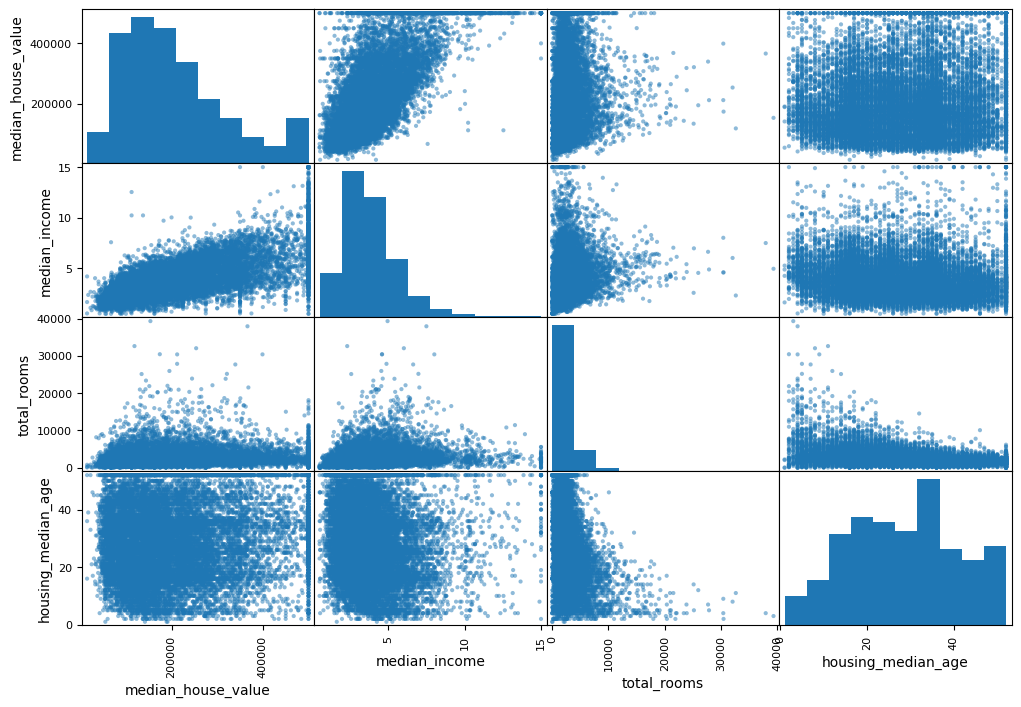

In [25]:
from pandas.plotting import scatter_matrix

attributes= ['median_house_value', "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize= (12, 8))
plt.show()

*It's the median house value and median income which seem highly correlated*

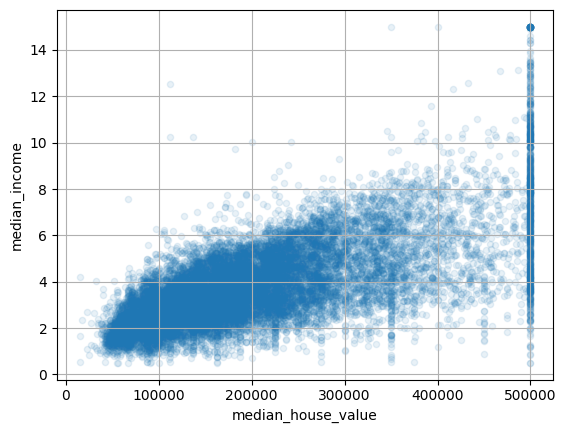

In [26]:
housing.plot(kind="scatter", x="median_house_value", y="median_income", alpha= 0.1, grid= True)
plt.show()

*The cap at **500k** now is highly apparent*

*Let's try and add some more attributes*

In [27]:
housing['rooms_per_house'] = housing['total_rooms']/ housing['households']
housing['bedrooms_ratio'] = housing['total_bedrooms']/ housing['total_rooms']
housing['people_per_house'] = housing['population']/ housing['households']

In [28]:
corr_matrix= housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.686589
rooms_per_house       0.160212
total_rooms           0.129365
housing_median_age    0.109071
households            0.063986
total_bedrooms        0.048503
people_per_house     -0.020061
population           -0.025065
longitude            -0.047023
latitude             -0.142816
bedrooms_ratio       -0.254250
Name: median_house_value, dtype: float64

There we go, both our **rooms_per_house** and **bedrooms_ratio** seem pretty imp features now

## Time for data pre processing

In [29]:
housing= strat_train_set.drop('median_house_value', axis= 1) ## We revert back to org train set
housing_labels = strat_train_set['median_house_value'].copy()

In [30]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12120 to 6778
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16357 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


In [31]:
"""
Three ways to deal with NaN values...
1) Drop the corresponding districts -> housing.dropna(subset = ['total_bedrooms'], inplace= True)
2) Drop the entire feature -> housing.drop('total_bedrooms', axis=1)
3) Imputation -> median= housing['total_bedrooms'].median() .. housing['total_bedrooms'].fillna(median, inplace= True)
"""


"\nThree ways to deal with NaN values...\n1) Drop the corresponding districts -> housing.dropna(subset = ['total_bedrooms'], inplace= True)\n2) Drop the entire feature -> housing.drop('total_bedrooms', axis=1)\n3) Imputation -> median= housing['total_bedrooms'].median() .. housing['total_bedrooms'].fillna(median, inplace= True)\n"

In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

In [33]:
housing_num = housing.select_dtypes(include= [np.number])
imputer.fit(housing_num)

SimpleImputer()

In [34]:
imputer.strategy

'mean'

In [35]:
imputer.statistics_

array([-119.57142442,   35.62961846,   28.61797481, 2636.86409884,
        537.76713334, 1427.31976744,  499.70367006,    3.87369089])

In [36]:
housing_num.median().values

array([-118.5    ,   34.26   ,   29.     , 2123.     ,  433.     ,
       1165.     ,  408.     ,    3.53775])

In [37]:
X = imputer.transform(housing_num)

In [38]:
X

array([[-1.1858e+02,  3.4220e+01,  3.5000e+01, ...,  9.5000e+02,
         3.4000e+02,  4.8750e+00],
       [-1.1848e+02,  3.4160e+01,  3.0000e+01, ...,  1.4270e+03,
         5.2500e+02,  6.7082e+00],
       [-1.1730e+02,  3.3060e+01,  2.4000e+01, ...,  8.7000e+02,
         4.4200e+02,  3.1940e+00],
       ...,
       [-1.2201e+02,  3.7360e+01,  2.5000e+01, ...,  1.2670e+03,
         4.2600e+02,  6.6329e+00],
       [-1.1721e+02,  3.3930e+01,  4.0000e+00, ...,  5.4390e+03,
         1.3970e+03,  5.0223e+00],
       [-1.1821e+02,  3.4090e+01,  3.9000e+01, ...,  1.7800e+03,
         3.9100e+02,  2.4632e+00]])

In [39]:
housing_tr = pd.DataFrame(X, columns = housing_num.columns, index = housing_num.index)
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12120 to 6778
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


### Text and Categorical Attributes

In [40]:
housing_cat= housing[['ocean_proximity']]

In [41]:
housing_cat

,ocean_proximity
12120,<1H OCEAN
13461,<1H OCEAN
11107,NEAR OCEAN
15946,INLAND
137,NEAR OCEAN
...,...
14221,NEAR OCEAN
18727,<1H OCEAN
19171,<1H OCEAN
898,INLAND


In [42]:
housing_cat.value_counts()

ocean_proximity
<1H OCEAN          7340
INLAND             5226
NEAR OCEAN         2111
NEAR BAY           1830
ISLAND                5
Name: count, dtype: int64

In [43]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder= OneHotEncoder()
housing_cat_1hot= cat_encoder.fit_transform(housing_cat)

In [44]:
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

***Sparse Matrix** is used when we have loads of 0s to fill, it helps managing memory efficiently. It only remembers the non 0s and their location in the matrix*

In [45]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [46]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [47]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

## Feature Scaling and Transformation

***Min Max Scaling*** -> subtracts min from each value and then divides by range (max- min).. normalisaton

In [48]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaled = MinMaxScaler(feature_range = (-1,1))
housing_num_min_max_scaled = min_max_scaled.fit_transform(housing_num)

**Standard Scaler** -> subtract mean from each val and then divide by standard deviation.. less affected by outliers

In [49]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled= std_scaler.fit_transform(housing_num)

Handing heavy tail fns

1) sqr root
2) raise to a power bw (0,1)
3) log
4) bucketizing
5) multimodal fns -> bucketize or similarity measure (rbf kernel)

<Axes: >

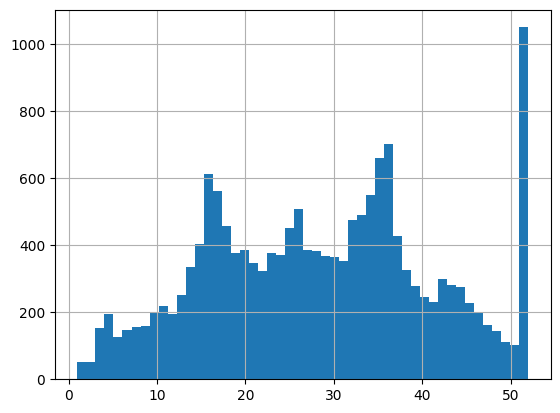

In [50]:
housing['housing_median_age'].hist(bins=50)

In [51]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[['housing_median_age']], [[35]], gamma= 0.1)

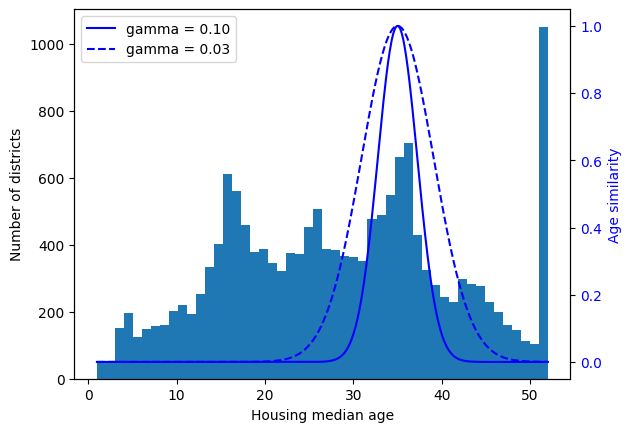

In [52]:
ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
plt.show()

In [53]:
## Check correlation with the above feature at the end

In [54]:
from sklearn.linear_model import LinearRegression

target_scaler= StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[['median_income']], scaled_labels)
some_new_data = housing[['median_income']].iloc[:5]

scaled_predictions= model.predict(some_new_data)
predictions= target_scaler.inverse_transform(scaled_predictions)

In [55]:
predictions

array([[248693.62118917],
       [325066.29149521],
       [178661.73226028],
       [269053.27860711],
       [178865.87042551]])

In [56]:
## use TransformedTargetRegressor

In [57]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                  transformer= StandardScaler())

In [58]:
model.fit(housing[['median_income']], housing_labels)

TransformedTargetRegressor(regressor=LinearRegression(),
                           transformer=StandardScaler())

In [59]:
predictions= model.predict(some_new_data)
predictions

array([248693.62118917, 325066.29149521, 178661.73226028, 269053.27860711,
       178865.87042551])

the above ->
1) scales the labels first
2) trains model on scaled values
3) upon making a prediciton, makes it on the scaled range
4) unscales it using the inverse_transform method
5) then returns the value

### Custom Transformers

In [60]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func= np.exp)
log_pop = log_transformer.transform(housing[['population']])

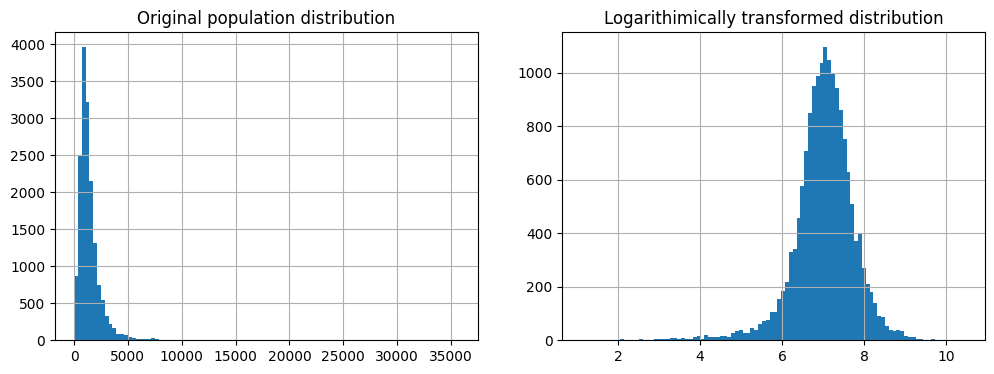

In [84]:
fig, axes= plt.subplots(1, 2, figsize=(12,4))

plt.sca(axes[0])
plt.hist(housing["population"], bins=100)
plt.title("Original population distribution")
plt.grid()

plt.sca(axes[1])
plt.hist(log_pop, bins = 100)
plt.title("Logarithimically transformed distribution")
plt.grid()

plt.show()

*Clearly, after the log transformation, we can see it following a **Gaussian** distribution*

In [127]:
housing_labels.corr(housing["population"])

-0.02506512912530618

In [128]:
housing_labels.corr(log_pop.squeeze())

-0.025216904678269682

*Improved correlation a little bit, but not much.. clearly no silver bullet over here*

In [117]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args= dict(Y=[[35.]], gamma= 0.1))
age_simil_35 = rbf_transformer.transform(housing[['housing_median_age']])

In [86]:
age_simil_35

array([[1.00000000e+00],
       [8.20849986e-02],
       [5.55951324e-06],
       ...,
       [4.53999298e-05],
       [1.83780864e-42],
       [2.01896518e-01]])

In [87]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel, 
                                    kw_args = dict(Y= [sf_coords], gamma= 0.1))
sf_simil= sf_transformer.transform(housing[['latitude', 'longitude']])

In [88]:
sf_simil

array([[0.06517877],
       [0.05777263],
       [0.00795274],
       ...,
       [0.96733133],
       [0.01526297],
       [0.04407561]])

*How close to San Francisco are we?*

<Axes: xlabel='longitude', ylabel='latitude'>

<Figure size 1000x600 with 0 Axes>

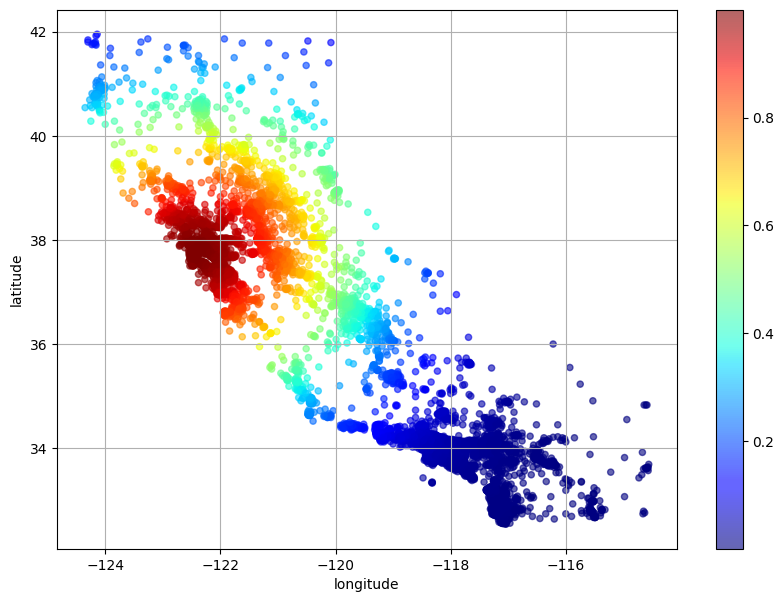

In [89]:
plt.figure(figsize= (10,6))

housing.plot(kind="scatter", x="longitude", y="latitude", grid = True, 
            c= sf_simil.ravel(), cmap = 'jet', colorbar= True, 
            alpha=0.6, sharex= False, legend= True, figsize = (10,7))


In [90]:
ratio_transformer = FunctionTransformer(lambda X: X[:,[0]]/ X[:,[1]])
ratio_transformer.transform(np.array([[1,2],[3,4]]))

array([[0.5 ],
       [0.75]])

In [91]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin): ## Base Estimator lets us have get and set_params()...
    ##TransformerMixin allows for .fit_transform()
    def __init__ (self, with_mean = True):
        self.with_mean = with_mean

    def fit(self, X, y= None): 
        X= check_array(X)
        self.mean_ = X.mean(axis= 0)
        self.scale_ = X.std(axis= 0)
        self.n_features_in_ = X.shape[1] 
        return self

    def transform(self, X):
        check_is_fitted(self)
        X= check_array(X) 
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X- self.mean_ 
        return X/self.scale_

In [92]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__ (self, n_clusters = 10, gamma=1.0, random_state= None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state= random_state

    def fit(self, X, y=None, sample_weight= None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight= sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [94]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)
similarities= cluster_simil.fit_transform(housing[['latitude', 'longitude']], 
                                         sample_weight = housing_labels)

In [130]:
similarities.max(axis=1)

array([0.89635988, 0.95514504, 0.92033823, ..., 0.90374452, 0.73384919,
       0.9894696 ])

In [133]:
similarities[:3].round(2)

array([[0.  , 0.45, 0.  , 0.05, 0.02, 0.  , 0.  , 0.76, 0.  , 0.9 ],
       [0.  , 0.54, 0.  , 0.04, 0.03, 0.  , 0.  , 0.67, 0.  , 0.96],
       [0.  , 0.43, 0.  , 0.  , 0.92, 0.  , 0.  , 0.01, 0.  , 0.14]])

In [129]:
cluster_simil.kmeans_.cluster_centers_

array([[  37.62566727, -122.18501276],
       [  33.84921311, -117.76038642],
       [  36.70401688, -119.71886438],
       [  34.80107258, -120.18517578],
       [  32.9503948 , -117.03354036],
       [  40.69953752, -123.84424791],
       [  39.69291726, -122.15151668],
       [  34.45138809, -119.044453  ],
       [  38.35911767, -121.16021398],
       [  34.04216615, -118.30109426]])

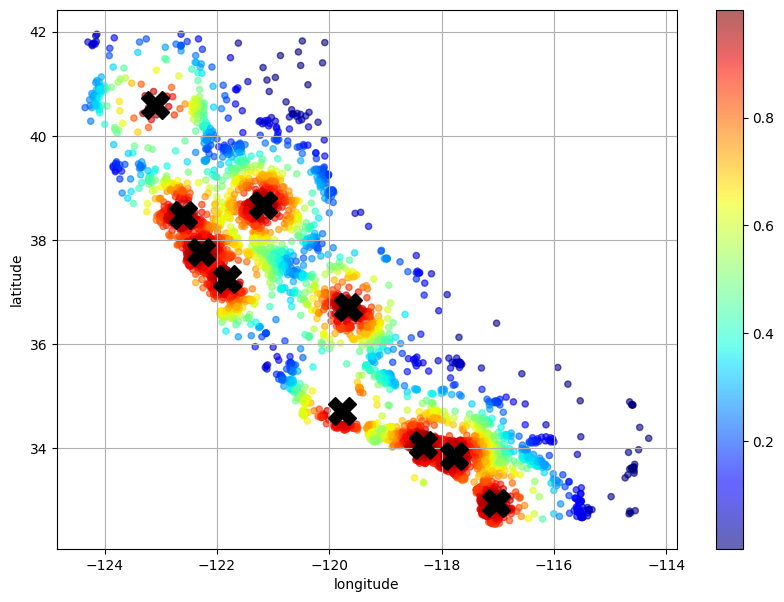

In [69]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid = True, 
            c= similarities.max(axis=1), cmap = 'jet', colorbar= True, 
            alpha=0.6, sharex= False, legend= True, figsize = (10,7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")

In [132]:
housing.shape

(16512, 9)

Pipeline constructor takes a list of name/estimator pairs defining a sequence of steps... estimators must be all transformers.. have a fit.transform()
method except for the last one which can be anything ... transformer/ predictor...

In [134]:
from sklearn.pipeline import Pipeline

num_pipeline= Pipeline([
    ('impute', SimpleImputer(strategy= 'median')),
    ('standardize', StandardScaler()),
])

In [135]:
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('standardize', StandardScaler())])

In [138]:
housing_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12120 to 6778
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16357 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [139]:
housing_num_prepared= num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[ 0.49, -0.66,  0.51, -0.3 , -0.46, -0.41, -0.41,  0.53],
       [ 0.54, -0.69,  0.11,  0.39, -0.  , -0.  ,  0.07,  1.49]])

In [173]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns= num_pipeline.get_feature_names_out(),
    index= housing_num.index
)

In [174]:
df_housing_num_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12120,0.494941,-0.661209,0.507409,-0.301560,-0.464584,-0.413297,-0.410419,0.526176
13461,0.544863,-0.689353,0.109879,0.392892,-0.001841,-0.000277,0.065009,1.489502
11107,1.133946,-1.205330,-0.367157,-0.210351,-0.060565,-0.482567,-0.148291,-0.357170
15946,0.914288,-0.712807,-0.049133,0.387022,0.068628,-0.031448,0.057299,0.782982
137,0.190416,-0.694044,0.189385,0.694514,1.097468,1.630157,1.167487,-0.354595
...,...,...,...,...,...,...,...,...
14221,-0.543441,-0.173377,-1.082710,1.310852,1.837388,0.827495,1.709731,-0.845033
18727,0.614755,-0.694044,0.904939,0.194671,0.514928,-0.205488,0.501888,-0.162897
19171,-1.217391,0.811670,-0.287651,0.071855,-0.253179,-0.138816,-0.189410,1.449932
898,1.178876,-0.797240,-1.957276,3.325577,2.187381,3.473594,2.305943,0.603581


In [142]:
num_pipeline.steps

[('impute', SimpleImputer(strategy='median')),
 ('standardize', StandardScaler())]

In [143]:
df_housing_num_prepared.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12120 to 6778
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


All **NaNs** in total_bedrooms clearly filled at this point

In [144]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

In [145]:
from sklearn.compose import ColumnTransformer

num_attribs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
               'total_bedrooms', 'population', 'households', 'median_income']
cat_attribs = ['ocean_proximity']


cat_pipeline= make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore'))

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs),
])

In [146]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing= make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)

In [147]:
housing_prepared= preprocessing.fit_transform(housing)

In [148]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12120,-118.58,34.22,35.0,1969.0,339.0,950.0,340.0,4.8750,<1H OCEAN
13461,-118.48,34.16,30.0,3507.0,536.0,1427.0,525.0,6.7082,<1H OCEAN
11107,-117.30,33.06,24.0,2171.0,511.0,870.0,442.0,3.1940,NEAR OCEAN
15946,-117.74,34.11,28.0,3494.0,566.0,1391.0,522.0,5.3637,INLAND
137,-119.19,34.15,31.0,4175.0,1004.0,3310.0,954.0,3.1989,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...
14221,-120.66,35.26,15.0,5540.0,1319.0,2383.0,1165.0,2.2656,NEAR OCEAN
18727,-118.34,34.15,40.0,3068.0,756.0,1190.0,695.0,3.5637,<1H OCEAN
19171,-122.01,37.36,25.0,2796.0,429.0,1267.0,426.0,6.6329,<1H OCEAN
898,-117.21,33.93,4.0,10002.0,1468.0,5439.0,1397.0,5.0223,INLAND


In [149]:
housing_prepared

array([[ 0.49494123, -0.66120931,  0.50740914, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.54486347, -0.68935349,  0.10987926, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.13394585, -1.20533016, -0.36715659, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-1.21739144,  0.81166955, -0.28765062, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17887586, -0.79723952, -1.9572761 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.6796535 , -0.72218837,  0.82543304, ...,  0.        ,
         0.        ,  0.        ]])

In [150]:
housing_prepared = pd.DataFrame(housing_prepared, columns= preprocessing.get_feature_names_out(), index= housing.index)

In [151]:
housing_prepared

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
12120,0.494941,-0.661209,0.507409,-0.301560,-0.464584,-0.413297,-0.410419,0.526176,1.0,0.0,0.0,0.0,0.0
13461,0.544863,-0.689353,0.109879,0.392892,-0.001841,-0.000277,0.065009,1.489502,1.0,0.0,0.0,0.0,0.0
11107,1.133946,-1.205330,-0.367157,-0.210351,-0.060565,-0.482567,-0.148291,-0.357170,0.0,0.0,0.0,0.0,1.0
15946,0.914288,-0.712807,-0.049133,0.387022,0.068628,-0.031448,0.057299,0.782982,0.0,1.0,0.0,0.0,0.0
137,0.190416,-0.694044,0.189385,0.694514,1.097468,1.630157,1.167487,-0.354595,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14221,-0.543441,-0.173377,-1.082710,1.310852,1.837388,0.827495,1.709731,-0.845033,0.0,0.0,0.0,0.0,1.0
18727,0.614755,-0.694044,0.904939,0.194671,0.514928,-0.205488,0.501888,-0.162897,1.0,0.0,0.0,0.0,0.0
19171,-1.217391,0.811670,-0.287651,0.071855,-0.253179,-0.138816,-0.189410,1.449932,1.0,0.0,0.0,0.0,0.0
898,1.178876,-0.797240,-1.957276,3.325577,2.187381,3.473594,2.305943,0.603581,0.0,1.0,0.0,0.0,0.0


In [152]:
## Creating the one and final pipeline

All the transformations being applied:

**1.** Simple imputer to fill NaN values  
**2.** one hot encoding the categorical features  
**3.** combining a few features for more relevance (*rooms_per_house*..etc)  
**4.** cluster similarity features instead of lat and long  
**5.** log transformations for features with long tail  
**6.** standardization  


In [153]:
def column_ratio(X):
    return X[:, [0]]/ X[:, [1]]   

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out='one-to-one'),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1, random_state=42)
default_num_pipeline= make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

preprocessing= ColumnTransformer([
        ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
        ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households']),
        ('people_per_house', ratio_pipeline(), ['population', 'households']),
        ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
        ('geo', cluster_simil, ['latitude', 'longitude']),
        ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder= default_num_pipeline) # housing_median_age

In [154]:
housing_prepared= preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [155]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

### Time to actually train a model

In [156]:
from sklearn.linear_model import LinearRegression

lin_reg= make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000024A9E0CA570>)])),
                ('linearregression', LinearRegression())])

In [158]:
housing_predictions= lin_reg.predict(housing)
housing_predictions[:5].round(-2)

array([301000., 348300., 228800., 245900., 222600.])

In [159]:
housing_labels.iloc[:5].values

array([230400., 500001., 276300., 214700., 185400.])

*Kinda massively off, don't we think*

In [160]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)

In [161]:
lin_rmse

69335.84462528458

would be interesting to see how much our preprocessing really helped.. let's have a look

In [163]:
lin_reg2 = LinearRegression()

In [176]:
lin_reg2.fit(df_housing_num_prepared, housing_labels)

LinearRegression()

In [177]:
housing_predictions= lin_reg2.predict(df_housing_num_prepared)
lin_rmse2 = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse2

69754.1439940385

*Really not much.. that's shocking to be fair... Basic standardization and simple imputer are matching everything we've done..*

*Let's try and remove features that don't correlate much and just see what diff does it make..*

In [184]:
df_housing_num_prepared.corrwith(housing_labels).sort_values(ascending= False)

median_income         0.686589
total_rooms           0.129365
housing_median_age    0.109071
households            0.063986
total_bedrooms        0.048283
population           -0.025065
longitude            -0.047023
latitude             -0.142816
dtype: float64

In [186]:
lin_reg3= LinearRegression()
lin_reg3.fit(df_housing_num_prepared.drop(["population", "latitude", "longitude", "households", "total_bedrooms"], axis =1), housing_labels)

LinearRegression()

In [189]:
housing_predictions= lin_reg3.predict(df_housing_num_prepared.drop(["population", "latitude", "longitude", "households", "total_bedrooms"], axis=1))
lin_rmse3 = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse3

80666.96169868567

Okay, at this point it is fair to assume **Linear Regression** was probably not the best model for this..

Let us give **Decision Trees** a shot

In [190]:
from sklearn.tree import DecisionTreeRegressor
tree_reg= make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

housing_predictions= tree_reg.predict(housing)
tree_rmse= root_mean_squared_error(housing_labels, housing_predictions)

tree_rmse

0.0

*Wtf...*

In [191]:
from sklearn.model_selection import cross_val_score

tree_rmses= -cross_val_score(tree_reg, housing, housing_labels, 
                            scoring= "neg_root_mean_squared_error", cv=10) 
## negative rmse cause cval expects a utility function (where greater is better) instead of loss function which needs to be minimised...

In [192]:
tree_rmses

array([66979.83983161, 64445.29769462, 69965.4214849 , 67194.27142863,
       71352.07425651, 69948.2868629 , 62909.20294887, 67107.33462922,
       65968.4426054 , 74033.19027996])

In [193]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     67990.336202
std       3340.985907
min      62909.202949
25%      66221.291912
50%      67150.803029
75%      69961.137829
max      74033.190280
dtype: float64

*Lol..ok... so that's the model hallucinating.. clearly overfiited, if we check it out on the test set, it'll have at best **~62k rmse** .. not much better than what we had with linear regression.*

*Let us try applying some kind of regularizations on our decision tree*

In [198]:
actual_tree= tree_reg.named_steps["decisiontreeregressor"]

In [199]:
actual_tree.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [201]:
actual_tree.get_depth()

38

In [202]:
actual_tree.get_n_leaves()

15750

*that's clearly a lot of leaves and pretty deep... obviously, we have to regularize this..*

In [208]:
new_tree_reg= make_pipeline(preprocessing, DecisionTreeRegressor(max_depth=30, min_samples_leaf=5, min_samples_split= 20, random_state=42))
new_tree_reg.fit(housing, housing_labels)

housing_predictions= new_tree_reg.predict(housing)
tree_rmse= root_mean_squared_error(housing_labels, housing_predictions)

tree_rmse

36589.73891333891

There we go, that's pretty nice, we almost halved our rmse.. we're getting into **actually decent** levels now.

In [204]:
## Let's just try this agaain
tree_rmses= -cross_val_score(new_tree_reg, housing, housing_labels, 
                            scoring= "neg_root_mean_squared_error", cv=10) 

In [205]:
tree_rmses

array([58203.18854419, 55513.48968514, 61436.43871174, 56982.71952314,
       60067.58159592, 60065.57461832, 56717.19155474, 58656.11511412,
       56002.39093112, 60814.81178902])

*Shit..*

In [209]:
final_tree_reg= make_pipeline(preprocessing, DecisionTreeRegressor(max_depth=25, min_samples_leaf=10, min_samples_split= 30, random_state=42))
final_tree_reg.fit(housing, housing_labels)

housing_predictions= final_tree_reg.predict(housing)
tree_rmse= root_mean_squared_error(housing_labels, housing_predictions)

tree_rmse

42125.007489458396

In [210]:
## Let's just try this agaain
tree_rmses= -cross_val_score(final_tree_reg, housing, housing_labels, 
                            scoring= "neg_root_mean_squared_error", cv=10) 
tree_rmses

array([58154.22099504, 52335.38048846, 60785.433856  , 56098.84026102,
       59352.27096604, 57769.42166611, 55325.33784462, 57479.39598187,
       55202.81541535, 58957.66173029])

*Ugh.. is 52k the best we can do... Let's turn to Random Forests*

In [211]:
from sklearn.ensemble import RandomForestRegressor

forest_reg= make_pipeline(preprocessing, 
                        RandomForestRegressor(random_state=42))

forest_rmses= -cross_val_score(forest_reg, housing, housing_labels, 
                              scoring= 'neg_root_mean_squared_error', cv=10)

In [212]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47091.205907
std       2224.115698
min      43941.271196
25%      45608.735990
50%      47133.282502
75%      49105.055908
max      49914.451272
dtype: float64

In [213]:
forest_reg.fit(housing, housing_labels)

housing_predictions= forest_reg.predict(housing)
forest_rmse= root_mean_squared_error(housing_labels, housing_predictions)

forest_rmse

17462.97424454037

*Well, there is a significant gap between 17k and 47k.. that has to be bridged by more regularization.. currently, our model is **overfitting***

### Grid Search

In [215]:
from sklearn.model_selection import GridSearchCV

full_pipeline= Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42))
])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
    'random_forest__max_features': [4, 6, 8]}, 
    {'preprocessing__geo__n_clusters': [10,15],
    'random_forest__max_features': [6, 8, 10]},
]

grid_search= GridSearchCV(full_pipeline, param_grid, cv= 3, 
                         scoring= 'neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x0000024A9E0CA570>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

grid_search.best_params_

In [222]:
best_est = grid_search.best_estimator_

best_est.fit(housing, housing_labels)

housing_predictions= best_est.predict(housing)
gs_rmse= root_mean_squared_error(housing_labels, housing_predictions)

gs_rmse

16077.730436763475

*Looks good but let's confirm our suspicions*

In [223]:
gs_rmses= -cross_val_score(best_est, housing, housing_labels, 
                              scoring= 'neg_root_mean_squared_error', cv=10)

In [224]:
gs_rmses

array([42982.73224953, 40504.82638359, 46016.59649775, 43070.9879462 ,
       44985.68586081, 42398.71283371, 39894.89751955, 41997.42326895,
       42200.73735408, 45119.95142749])

*Yeah well, fuck*

In [218]:
cv_res= pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by= "mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,6.379485,0.053372,0.161307,0.003222,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-44084.424589,-43897.581773,-44073.552567,-44018.519643,85.631094,1
13,8.207081,0.048082,0.167932,0.004562,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-44619.586010,-44297.363130,-44475.433137,-44464.127426,131.789631,2
14,10.382163,0.436793,0.162439,0.008116,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-45037.760140,-44878.724006,-44887.161716,-44934.548621,73.062813,3
7,6.362651,0.110988,0.161693,0.002124,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-45108.745382,-45309.246141,-44742.872017,-45053.621180,234.483717,4
9,6.351307,0.189156,0.160435,0.012187,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-45108.745382,-45309.246141,-44742.872017,-45053.621180,234.483717,4


In [219]:
full_pipeline


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000024...
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000024A9E0CA570>)])),
                ('random_forest', RandomForestRegressor(random_state=42))])

In [226]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs= {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                'random_forest__max_features': randint(low=2, high= 20)}

rnd_search= RandomizedSearchCV(
    full_pipeline, param_distributions= param_distribs, n_iter=10, cv=3, 
    scoring= 'neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024AA1C66990>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000024AA1B42DE0>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [227]:
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}

In [228]:
rnd_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000024...
                                                                    n_clusters=45,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000024AA13B59A0>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=9, random_state=42))])

In [229]:
rv_res= pd.DataFrame(rnd_search.cv_results_)
rv_res.sort_values(by= "mean_test_score", ascending=False, inplace=True)
rv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,9.459778,0.102435,0.171514,0.006835,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-42511.802850,-42280.271290,-41984.188880,-42258.754340,215.934187,1
8,7.499261,0.045791,0.171967,0.003549,32,7,"{'preprocessing__geo__n_clusters': 32, 'random...",-42683.612888,-42446.253505,-42585.985612,-42571.950668,97.408432,2
5,4.835124,0.044693,0.165001,0.003400,42,4,"{'preprocessing__geo__n_clusters': 42, 'random...",-42871.578714,-42966.938410,-42571.562902,-42803.360009,168.465213,3
0,16.317713,0.213481,0.165670,0.002454,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-43209.043408,-42692.990561,-43166.592444,-43022.875471,233.906764,4
2,8.312246,0.072932,0.175087,0.018126,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-43491.091805,-43279.107051,-42978.668940,-43249.622599,210.232091,5


In [230]:
final_model = rnd_search.best_estimator_
feature_importances= final_model['random_forest'].feature_importances_

In [231]:
feature_importances.round(3)

array([0.069, 0.053, 0.048, 0.007, 0.008, 0.007, 0.007, 0.186, 0.011,
       0.004, 0.016, 0.018, 0.01 , 0.002, 0.004, 0.011, 0.013, 0.014,
       0.004, 0.011, 0.011, 0.004, 0.008, 0.012, 0.012, 0.006, 0.012,
       0.005, 0.013, 0.01 , 0.008, 0.023, 0.008, 0.015, 0.016, 0.004,
       0.014, 0.008, 0.007, 0.014, 0.029, 0.014, 0.013, 0.025, 0.01 ,
       0.009, 0.038, 0.004, 0.028, 0.005, 0.003, 0.005, 0.008, 0.002,
       0.075, 0.   , 0.   , 0.003, 0.012])

In [232]:
sorted(zip(feature_importances, final_model['preprocessing'].get_feature_names_out()), reverse= True)

[(0.18639485824015273, 'log__median_income'),
 (0.07536455668446701, 'cat__ocean_proximity_INLAND'),
 (0.06944639070464753, 'bedrooms__ratio'),
 (0.05255300177125852, 'rooms_per_house__ratio'),
 (0.04752300555582737, 'people_per_house__ratio'),
 (0.03757599386664734, 'geo__Cluster 38 similarity'),
 (0.029060377917159912, 'geo__Cluster 32 similarity'),
 (0.028283376525342564, 'geo__Cluster 40 similarity'),
 (0.02530058662067303, 'geo__Cluster 35 similarity'),
 (0.0230680053604293, 'geo__Cluster 23 similarity'),
 (0.01832900352498936, 'geo__Cluster 3 similarity'),
 (0.01647904968063285, 'geo__Cluster 2 similarity'),
 (0.01595867007335931, 'geo__Cluster 26 similarity'),
 (0.015191596118416308, 'geo__Cluster 25 similarity'),
 (0.014457985353483718, 'geo__Cluster 9 similarity'),
 (0.013948228837596952, 'geo__Cluster 31 similarity'),
 (0.013930455866900306, 'geo__Cluster 28 similarity'),
 (0.01366862635606768, 'geo__Cluster 33 similarity'),
 (0.013467674002386068, 'geo__Cluster 20 similarity

In [233]:
X_test= strat_test_set.drop("median_house_value", axis=1)
y_test= strat_test_set['median_house_value'].copy()

final_predictions= final_model.predict(X_test)

final_rmse= root_mean_squared_error(y_test, final_predictions)
final_rmse

40972.70184036072

In [234]:
import joblib

joblib.dump(final_model, 'my_california_housing_model.pkl')

['my_california_housing_model.pkl']